## Create Model and Run

In [1]:
import sys
sys.path.append('..')
from datasets import load_dataset
from python_scripts import FlowExperiment, FlowModelConfig, Interpolant, prime_dataset, get_size_and_channel
import torch

# load the dataset
dataset_target = load_dataset("natejuw/mnist-28x28")

# get the image size and channel amount (should be 1 channel for grayscale and 3 channels for RGB)
# we assume that the input dataset has square images
IMAGE_SIZE, CHANNELS = get_size_and_channel(dataset_target)

# unet keeps images as (C, H, W), no flattening
dataset_target = prime_dataset(dataset_target, model_type='unet', img_size=IMAGE_SIZE)

# configure the model
cfg = FlowModelConfig(
    model_type   = 'unet',
    img_size     = IMAGE_SIZE,
    channels     = CHANNELS,
    unet_variant = 'unet_small',
)

# choose interpolant
interp = Interpolant('linear')

# create experiment
exp = FlowExperiment(cfg, interp, stepping='ode')

# train
history = exp.train(
    dataset_base   = dataset_target,
    dataset_target = dataset_target,
    n_iterations   = 5000,
    batch_size     = 256,
    base_lr        = 1e-3,
    log_every      = 200,
    rand_run       = True,
    out_name       = 'mnist_unet',
)

/home/njung3/miniconda3/envs/flow311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda
── Training velocity model ──
initial | obj 0.1001 | mse 2.1229 | pred_mean 0.1406 | pred_std 0.3502


Training velocity: 100%|██████████| 5000/5000 [25:51<00:00,  3.22it/s, obj=-0.8777, mse=0.1611, grad=0.042]

Saved to mnist_unet_velocity.pt


## Plot Loss and Visualise Flow

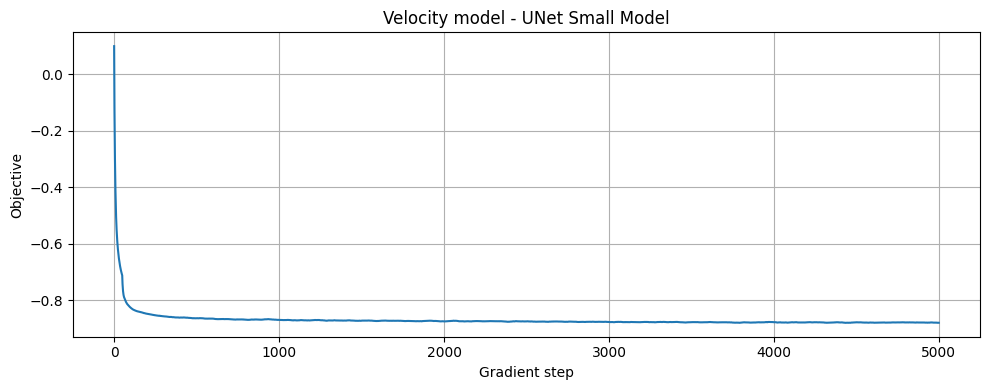

/tmp/ipykernel_1128124/930187572.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  sample   = torch.tensor(dataset_target['train']['pixel_values'][0])


Starting from dataset item 0


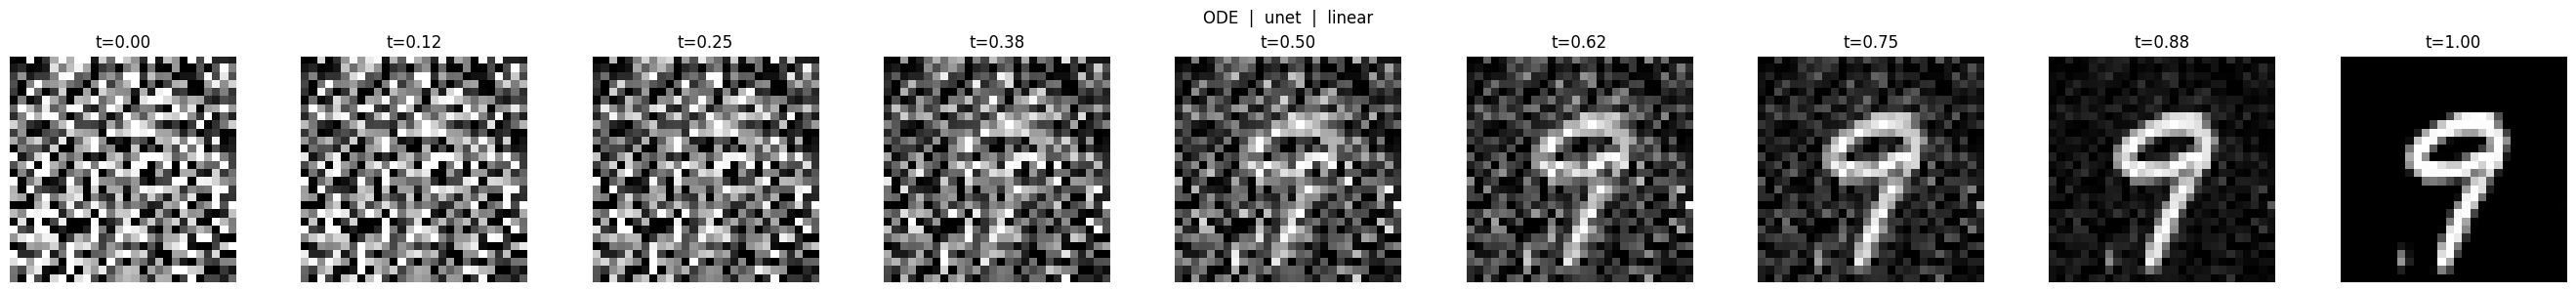

In [6]:
from python_scripts import plot_loss
from datasets import Dataset, DatasetDict

# plot the loss curve
plot_loss(history['velocity_loss'], title='Velocity model - UNet Small Model')
sample   = torch.tensor(dataset_target['train']['pixel_values'][0])
gaussian = torch.randn_like(sample)
dataset_base = DatasetDict({"train": Dataset.from_dict({"pixel_values": [gaussian.numpy()]})})

exp.visualise(
    dataset_base     = dataset_base,
    n_steps          = 1000,
    save_frames      = 9,
    use_random_start = True,
)

Create MLP Model with sin/cos time embedding. Consult https://www.kaggle.com/code/lorentzyeung/positional-embeddings-clearly-explained for more information on this type of time embedding.